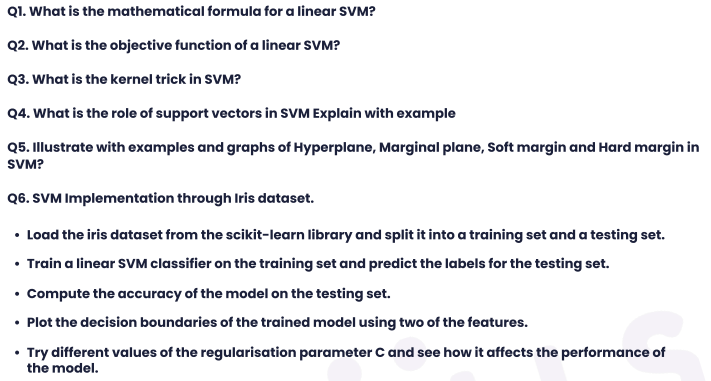

Q1. What is the mathematical formula for a linear SVM?

The decision boundary is represented by a linear function:
f(x)=w⋅x+b
Where:

𝑤: w is the weight vector, normal to the hyperplane.
𝑏: b is the bias term.
𝑥: x is the input feature vector.

Q2. The Objective Function for Linear SVM
The SVM optimization problem is typically formulated as a convex optimization problem, which can be expressed as:

minimize(w,b)1/2 ||w^2||

Q3. What is the kernel trick in SVM?

The kernel trick in Support Vector Machines (SVM) is a method used to enable SVM to perform non-linear classification by implicitly mapping the input data into a higher-dimensional feature space, without explicitly calculating the mapping. This allows the SVM to create non-linear decision boundaries, even though the SVM algorithm itself is inherently linear.

Q4. What is the role of support vectors in SVM Explain with example

In a Support Vector Machine (SVM), support vectors are the data points that play a crucial role in defining the decision boundary (hyperplane) that separates the classes. They are the closest points to the decision boundary and essentially "support" the optimal hyperplane. These points determine the margin—the distance between the hyperplane and the closest data points from either class.

Q5. Illustrate with examples and graphs of Hyperplane, Marginal plane, Soft margin and Hard margin in SVM?

1. Hyperplane
A hyperplane is a decision boundary that separates the data points belonging to different classes. In 2D, a hyperplane is just a line, while in 3D, it’s a plane. In higher-dimensional spaces, the hyperplane is a generalization of a flat subspace of one dimension less than the data space.

Example:
Consider a simple 2D dataset where we have two classes: Class +1 (represented by circles) and Class -1 (represented by crosses).

We want to find a line (the hyperplane) that separates these two classes.


2. Margin and Marginal Planes
The margin is the distance between the hyperplane and the closest data points from both classes, which are called support vectors.

The marginal planes are two parallel hyperplanes that lie on either side of the decision boundary. These planes pass through the support vectors and define the margin.
The SVM's goal is to maximize the margin, i.e., place the decision hyperplane equidistant from the support vectors of both classes.

The margin is the distance between the support vectors on either side of the decision boundary. The optimal hyperplane is the one that maximizes this margin.

3. Hard Margin (Linearly Separable Data)
A hard margin SVM applies when the data is linearly separable, meaning we can draw a perfect separating hyperplane that correctly classifies all the data points without error. In this case, we aim to find a hyperplane with no misclassifications.

Characteristics of Hard Margin:
No misclassifications are allowed.
The margin is maximized, and the decision boundary perfectly separates the two classes.

4. Soft Margin (Non-Linearly Separable Data)
A soft margin SVM allows for misclassifications and is typically used when the data is not linearly separable or when we allow for some flexibility in separating the classes. It introduces slack variables ξ  which allow some points to lie on the wrong side of the margin.

Characteristics of Soft Margin:
Allows some points to be misclassified.
The goal is to balance the margin maximization and penalizing misclassifications.
Controlled by a regularization parameter 𝐶 that determines the trade-off between margin size and classification error.

Q6. SVM Implementation through Iris dataset.

Accuracy of the SVM classifier: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



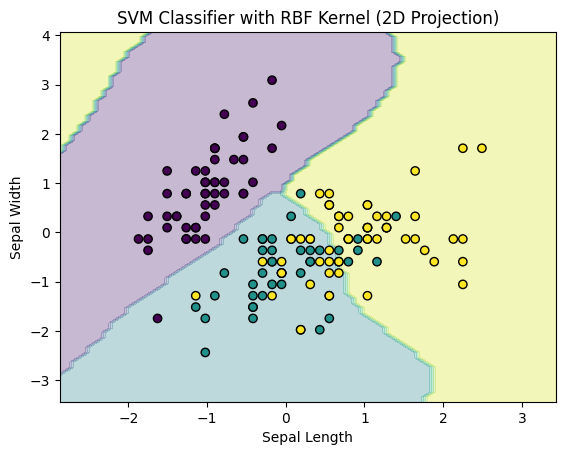

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 2. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Train the SVM classifier
svm = SVC(kernel='rbf', gamma='scale', C=1.0)
svm.fit(X_train, y_train)

# 5. Evaluate the model
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the SVM classifier:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. Visualization (using only the first two features)
X_vis = X_scaled[:, :2]  # Sepal length and sepal width
y_vis = y
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y_vis, test_size=0.2, random_state=42)

svm_vis = SVC(kernel='rbf', gamma='scale', C=1.0)
svm_vis.fit(X_train_vis, y_train_vis)

# Create a mesh grid for plotting decision boundaries
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Get the SVM predictions for the entire mesh
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, marker='o', edgecolors='k')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('SVM Classifier with RBF Kernel (2D Projection)')
plt.show()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])